In [1]:
# load module
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorboard as tb 
import pytorch_lightning as pl

from pathlib import Path
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters


import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'
#plt.rcParams['font.sans-serif'] = ['NanumGothic.ttf', 'sans-serif']

from my_funs import data_processing , get_training

/home/nplab/.local/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/nplab/.local/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will n

In [6]:
def get_val_dataloader(training , data , time_idx):
    batch_size= 32    
    test_data = data[data['time_idx'] < time_idx]
    validation = TimeSeriesDataSet.from_dataset(training, test_data, predict=True, stop_randomization=True)
    val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=1)
    return val_dataloader

def countious_prediction(training, tft ,ewma_data, dong, title):
    plt.figure(figsize=(16,4))
    predition3 , predition4, predition5, predition6 = np.array([]) , np.array([]) , np.array([]) , np.array([])
    for i in range(1,59):
        val_data = get_val_dataloader(training ,data, 8760+24*i)
        pred , x, idx_df = tft.predict(val_data, mode='raw', return_x = True , return_index = True)
        #print(idx_df['time_idx'].loc[0])
        dong_idx = idx_df[idx_df['h_dong'] == dong].index[0]
        predition3 = np.concatenate([predition3,pred['prediction'][dong_idx, : , 3]])
        predition4 = np.concatenate([predition4,pred['prediction'][dong_idx, : , 4]])
        predition5 = np.concatenate([predition5,pred['prediction'][dong_idx, : , 5]])
        predition6 = np.concatenate([predition6,pred['prediction'][dong_idx, : , 6]])
    
    ewma_dong_df = ewma_data[ewma_data['h_dong']==dong]
    ewma_df_index = ewma_dong_df[ewma_dong_df['time_idx'] > 8760-1]['REG_DTIME']
    ewma_org_count = ewma_dong_df[ewma_dong_df['time_idx'] > 8760-1]['count']
    
    org_df = data_processing('../../data/data.csv')
    dong_org_df = org_df[org_df['h_dong'] == dong]
    dong_org_count = dong_org_df[dong_org_df['time_idx'] > 8760-1]['count']
    
    plt.plot(ewma_df_index,dong_org_count , label = 'orginal target' , alpha=1)
    plt.plot(ewma_df_index,ewma_org_count , label = 'ewma target' , alpha=0.7)
    plt.plot(ewma_df_index,predition3 ,label = '50% prediction', alpha= 0.6, linestyle='--')
    plt.plot(ewma_df_index,predition4 ,label = '70% prediction', alpha= 0.6, linestyle='--')
    plt.plot(ewma_df_index,predition5 ,label = '90% prediction', alpha= 0.6, linestyle='--')
    plt.plot(ewma_df_index,predition6 ,label = '98% prediction', alpha= 0.6, linestyle='--')
    plt.title(f'{dong} {title}')
    plt.legend()

    '''
    plt.figure(figsize=(16,4))
    plt.plot(ewma_df_index,dong_org_count , label = 'orginal target' , alpha=1)
    plt.plot(ewma_df_index,ewma_org_count , label = 'ewma target' , alpha=0.7)
    plt.plot(ewma_df_index,predition3 ,label = '50% prediction', alpha= 0.6, linestyle='--')
    plt.title(f'{dong} {title}')
    plt.legend()
    
    plt.figure(figsize=(16,4))
    plt.plot(ewma_df_index,dong_org_count , label = 'orginal target' , alpha=1)
    plt.plot(ewma_df_index,ewma_org_count , label = 'ewma target' , alpha=0.7)
    plt.plot(ewma_df_index,predition4 ,label = '70% prediction', alpha= 0.6, linestyle='--')
    plt.title(f'{dong} {title}')
    plt.legend()
    
    plt.figure(figsize=(16,4))
    plt.plot(ewma_df_index,dong_org_count , label = 'orginal target' , alpha=1)
    plt.plot(ewma_df_index,ewma_org_count , label = 'ewma target' , alpha=0.7)
    plt.plot(ewma_df_index,predition5 ,label = '90% prediction', alpha= 0.6, linestyle='--')
    plt.title(f'{dong} {title}')
    plt.legend()
    
    plt.figure(figsize=(16,4))
    plt.plot(ewma_df_index,dong_org_count , label = 'orginal target' , alpha=1)
    plt.plot(ewma_df_index,ewma_org_count , label = 'ewma target' , alpha=0.7)
    plt.plot(ewma_df_index,predition6 ,label = '98% prediction', alpha= 0.6, linestyle='--')
    plt.title(f'{dong} {title}')
    plt.legend()
    '''

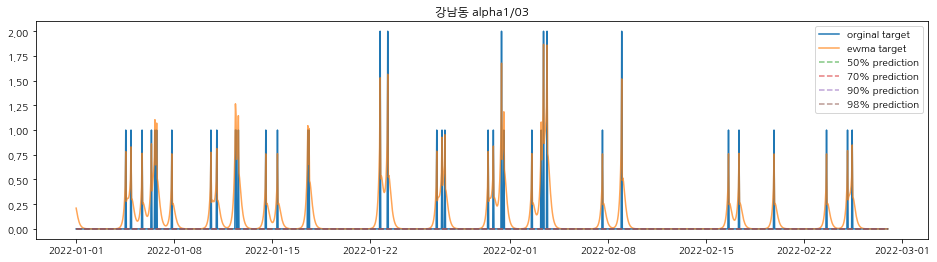

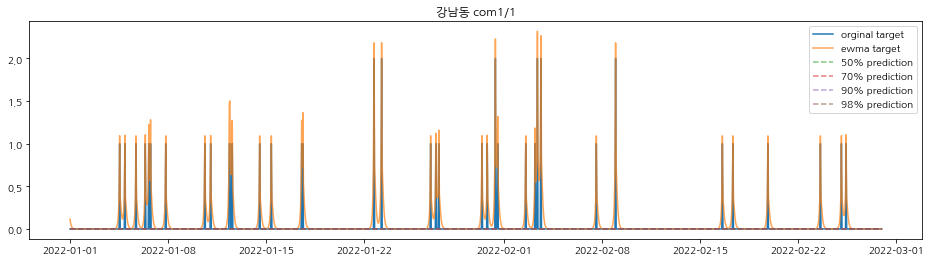

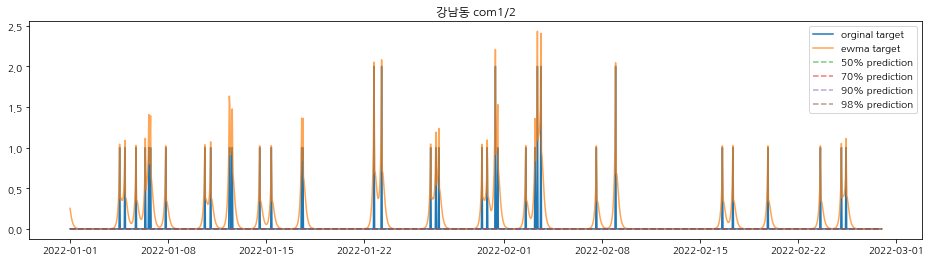

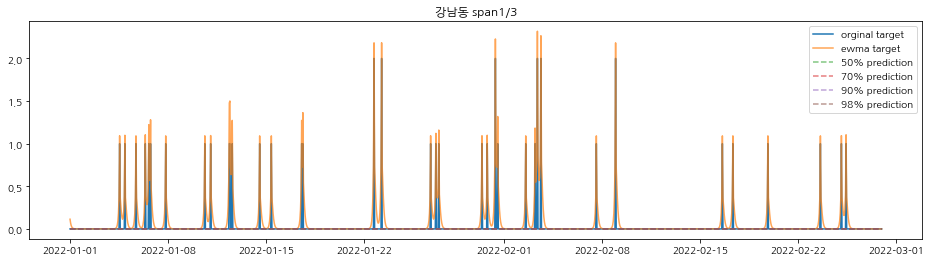

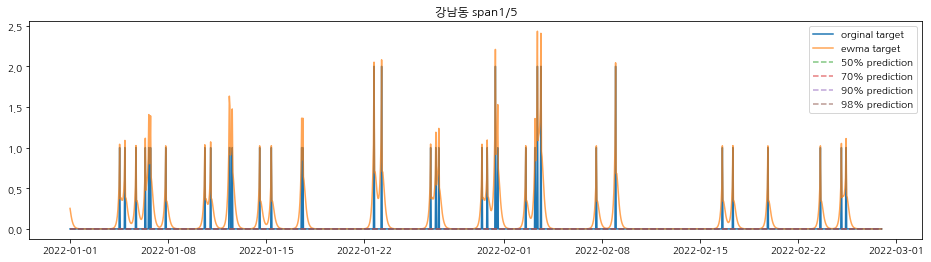

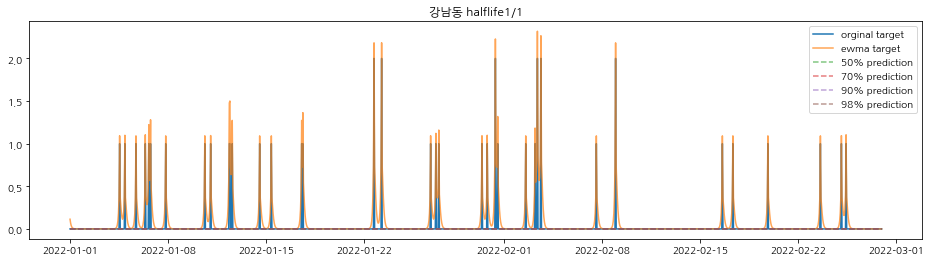

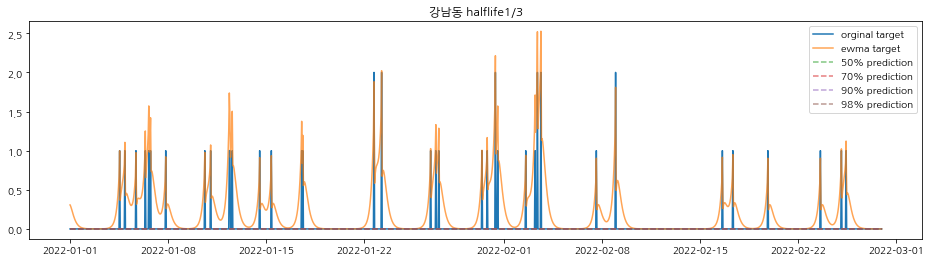

In [7]:
# best_ewma
result = {'alpha1/03.csv': 'best_ewma_lr_tuning/lightning_logs/version_5/checkpoints/epoch=29-step=150.ckpt',
 'com1/1.csv': 'best_ewma_lr_tuning/lightning_logs/version_6/checkpoints/epoch=29-step=150.ckpt',
 'com1/2.csv': 'best_ewma_lr_tuning/lightning_logs/version_7/checkpoints/epoch=29-step=150.ckpt',
 'span1/3.csv': 'best_ewma_lr_tuning/lightning_logs/version_8/checkpoints/epoch=29-step=150.ckpt',
 'span1/5.csv': 'best_ewma_lr_tuning/lightning_logs/version_9/checkpoints/epoch=29-step=150.ckpt',
 'halflife1/1.csv': 'best_ewma_lr_tuning/lightning_logs/version_10/checkpoints/epoch=29-step=150.ckpt',
 'halflife1/3.csv': 'best_ewma_lr_tuning/lightning_logs/version_11/checkpoints/epoch=29-step=150.ckpt'}

for fname in result:
    data = data_processing(fname)
    train_data = data[data['time_idx']  < 8760]
    training = get_training(train_data,24, 24*7)
    model_path = result[fname]
    tft = TemporalFusionTransformer.load_from_checkpoint(model_path)
    countious_prediction(training, tft, data, '강남동' , fname.split('.')[0])
    

In [9]:
%load_ext tensorboard
%tensorboard --logdir=./best_ewma_lr_tuning --port=9995 --load_fast=false --bind_all

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 9995 (pid 375905), started 0:02:45 ago. (Use '!kill 375905' to kill it.)